# Dynamic Hedge Pairs Trading — *without* Benjamini-Hochberg
## `pairs_trading_03.ipynb`

Identical pipeline to `pairs_trading_02.ipynb` — cointegration screen → Kalman hedge → walk-forward pair selection → in-sample & out-of-sample backtests with performance metrics → limitations — with **one deliberate change: no Benjamini-Hochberg FDR correction** on the cointegration screen (`fdr_method="none"`, raw p-values).

This isolates the effect of dropping multiple-testing control: the screen admits more (disproportionately spurious) pairs, and selection and evaluation then proceed from that uncorrected candidate set. It is a deliberate ablation, **not** a recommended default — see `pairs_trading_02.ipynb` for the BH-corrected version.

Re-run from top to bottom; self-contained.

## 0. Environment setup

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent           # notebooks/ → repo root
sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
print("pairs version:", pairs.__version__)
print("pairs path   :", pairs.__file__)

pairs version: 0.1.0
pairs path   : /Users/mengren/Documents/projects/coding_finance/dynamic-hedge-pairs-trading/pairs/__init__.py


In [2]:
# Install the package (editable) if running in a fresh environment
# %pip install -e "..[notebooks]"  # uncomment if needed

# 1. Data Loading & Quality Filtering

We load daily OHLCV prices for the combined S&P 500 + NASDAQ-100 universe
(~517 tickers) over the **training window 2020-01-01 → 2025-12-31**, then
drop tickers whose coverage does not span the full period.

In [3]:
from pairs import load_universe, load_prices

tickers = load_universe("spx_ndx_combined")
print(f"Universe: {len(tickers)} tickers")

Universe: 517 tickers


In [4]:
# ── Load training prices ──────────────────────────────────────────────────────
start_date = "2020-01-01"
end_date   = "2025-12-31"

df_train, failed = load_prices('openbb', tickers, start_date, end_date, return_failed=True)

print(f"Loaded {len(df_train):,} rows for {df_train.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)

Download:   0%|          | 0/517 [00:00<?, ?it/s]

A:   0%|          | 0/517 [00:00<?, ?it/s]       

A:   0%|          | 1/517 [00:03<33:34,  3.90s/it]

AAPL:   0%|          | 1/517 [00:03<33:34,  3.90s/it]

AAPL:   0%|          | 2/517 [00:06<28:25,  3.31s/it]

...

ZS: 100%|█████████▉| 516/517 [03:14<00:00,  3.04it/s]

ZTS: 100%|█████████▉| 516/517 [03:14<00:00,  3.04it/s]

ZTS: 100%|██████████| 517/517 [03:14<00:00,  2.92it/s]

ZTS: 100%|██████████| 517/517 [03:14<00:00,  2.65it/s]

Loaded 753,000 rows for 505 tickers
No data for: ['AVB', 'BK', 'CTRA', 'DAY', 'EA', 'EQR', 'FI', 'HOLX', 'IPG', 'K', 'MMC', 'WBA']


In [5]:
# ── Quality filter: keep only full-coverage tickers ──────────────────────────
lvl_names      = list(df_train.index.names)
time_lvl_name  = 'datetime' if 'datetime' in lvl_names else lvl_names[1]

full_start = df_train.index.get_level_values(time_lvl_name).min()
full_end   = df_train.index.get_level_values(time_lvl_name).max()

starts = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).min())
ends   = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).max())

tickers_to_keep = starts[(starts == full_start) & (ends == full_end)].index
df_filtered     = df_train.loc[pd.IndexSlice[tickers_to_keep, :]]

n_orig    = df_train.index.get_level_values('ticker').nunique()
n_kept    = df_filtered.index.get_level_values('ticker').nunique()
dropped   = set(tickers) - set(tickers_to_keep)
print(f"Tickers: {n_orig} total → {n_kept} kept ({n_orig - n_kept} dropped for incomplete coverage)")
print(f"Dropped: {sorted(dropped)}")

Tickers: 505 total → 488 kept (17 dropped for incomplete coverage)
Dropped: ['ABNB', 'APP', 'ARM', 'AVB', 'BK', 'CARR', 'CEG', 'COIN', 'CTRA', 'DASH', 'DAY', 'EA', 'EQR', 'EXE', 'FI', 'GEHC', 'GEV', 'GFS', 'HOLX', 'IPG', 'K', 'KVUE', 'MMC', 'OTIS', 'PARA', 'PLTR', 'SOLV', 'VLTO', 'WBA']


# 2. Cointegration Screening

## 2.1 Dual-gate screening (Engle-Granger + Johansen)

We test all $\binom{n}{2}$ pairs simultaneously using two cointegration tests.
A pair advances only if **both** tests reject the null of no cointegration.

In [6]:
from pairs import find_cointegrated_pairs_dualgate

# fdr_method="none" — NO Benjamini-Hochberg correction (raw EG p-value gate).
summary_dual = find_cointegrated_pairs_dualgate(
    df_filtered,
    alpha_eg=0.05, eg_trend="c",
    alpha_joh=0.05, joh_det_order=0, joh_k_ar_diff=1, joh_stat="trace",
    fdr_method="none",      # ← raw p-values, no multiple-testing correction
    n_workers=16, chunksize=8, show_progress=True,
)
print(f"\nTotal pairs screened : {len(summary_dual):,}")
print(f"Dual-gate pass (verdict=='pass'): {(summary_dual['verdict']=='pass').sum()}")
summary_dual.head(5)[["eg_t", "eg_p", "eg_pass", "joh_stat", "joh_pass", "verdict"]]

Dual-gate cointegration (EG + Johansen):   0%|          | 0/118828 [00:00<?, ?it/s]

Dual-gate cointegration (EG + Johansen):   1%|          | 1081/118828 [00:00<00:27, 4279.31it/s]

Dual-gate cointegration (EG + Johansen):   1%|▏         | 1509/118828 [00:00<01:20, 1453.35it/s]

Dual-gate cointegration (EG + Johansen):   1%|▏         | 1725/118828 [00:01<01:41, 1150.01it/s]

Dual-gate cointegration (EG + Johansen):   2%|▏         | 1872/118828 [00:01<02:06, 923.28it/s] 

...

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118649/118828 [03:39<00:00, 565.63it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118709/118828 [03:39<00:00, 507.76it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118809/118828 [03:39<00:00, 580.77it/s]


Total pairs screened : 118,828
Dual-gate pass (verdict=='pass'): 6102


eg_t          eg_p  eg_pass   joh_stat  joh_pass verdict
ticker1 ticker2                                                              
NCLH    SHOP    -6.892330  1.544746e-08     True  37.268515      True    pass
        TRMB    -6.774412  2.923744e-08     True  42.340817      True    pass
        ZBRA    -6.725933  3.793752e-08     True  36.397732      True    pass
        XYZ     -6.691579  4.559848e-08     True  34.453662      True    pass
        SBUX    -6.533492  1.055287e-07     True  38.528619      True    pass

## 2.2 Pre-scoring: rank candidates for Kalman filtering

We rank all pairs by a composite rank score (EG p-value + Johansen statistic) and
take the top 200 as candidates for the computationally expensive Kalman step.

In [7]:
tmp = summary_dual.copy()
tmp["rank_eg"]  = tmp["eg_p"].rank(method="average", ascending=True)
tmp["rank_joh"] = tmp["joh_stat"].rank(method="average", ascending=False)
tmp["pre_score"] = 0.5 * (tmp["rank_eg"] / tmp["rank_eg"].max()
                         + tmp["rank_joh"] / tmp["rank_joh"].max())
prelim     = tmp.sort_values("pre_score", ascending=True)
candidates = prelim.head(200).index.to_list()
print(f"Candidates selected for Kalman filtering: {len(candidates)}")

Candidates selected for Kalman filtering: 200


# 3. Kalman Filter Hedge Estimation & Stationarity Scoring

## 3.1 Kalman filter model overview

We estimate a **time-varying** hedge ratio $\beta_t$ via a linear Gaussian state-space model.

**State (random walk):**
$$
\theta_t = \begin{bmatrix}\beta_t \\ \alpha_t\end{bmatrix}, \qquad
\theta_t = \theta_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q)
$$

**Observation:**
$$
y_t = \alpha_t + \beta_t x_t + v_t, \quad v_t \sim \mathcal{N}(0, R)
$$

Parameters $Q$ and $R$ are learned by EM; the filter is then run in smoother mode
for in-sample residuals and in **filter mode** (no look-ahead) for OOS evaluation.

In [8]:
from pairs import fit_kalman_hedge, summarize_spread_stationarity_joblib

states_tr, params_tr = fit_kalman_hedge(
    df_train,
    pairs=candidates,
    mode="smooth",
    em_iters=5,
    q=1e-5,
    n_workers=None,
    chunksize=100,
    show_progress=True,
    return_params=True,
)
print(f"Kalman states computed for {len(states_tr)} pairs")

Kalman (α_t, β_t):   0%|          | 0/200 [00:00<?, ?it/s]

Kalman (α_t, β_t):   1%|          | 2/200 [00:03<05:49,  1.77s/it]

Kalman (α_t, β_t):   4%|▍         | 8/200 [00:03<01:06,  2.87it/s]

Kalman (α_t, β_t):   9%|▉         | 18/200 [00:03<00:22,  7.95it/s]

Kalman (α_t, β_t):  15%|█▌        | 30/200 [00:03<00:10, 15.70it/s]

...

Kalman (α_t, β_t):  96%|█████████▌| 191/200 [00:17<00:00, 17.02it/s]

Kalman (α_t, β_t):  96%|█████████▋| 193/200 [00:18<00:00, 12.03it/s]

Kalman (α_t, β_t):  98%|█████████▊| 195/200 [00:18<00:00, 10.76it/s]

Kalman (α_t, β_t):  98%|█████████▊| 197/200 [00:18<00:00, 11.42it/s]

Kalman states computed for 200 pairs


## 3.2 Spread stationarity diagnostics

For each pair we run:
1. **ADF** (Augmented Dickey-Fuller) — reject $H_0$ of unit root → spread is I(0)
2. **KPSS** — fail to reject $H_0$ of stationarity → spread is I(0)

**Verdict**: `stationary` if ADF rejects AND KPSS does not reject; `non-stationary` if vice versa;
`inconclusive` otherwise.

Additional diagnostics: **half-life** (AR(1) proxy for mean-reversion speed) and
**residual sigma** (spread volatility).

In [9]:
summary_stationarity = summarize_spread_stationarity_joblib(
    states_tr, alpha=0.05, regression="c", chunksize=256, show_progress=True
)
print(f"\n{len(summary_stationarity)} pairs tested")
summary_stationarity.head(10)

Testing stationarity:   0%|          | 0/200 [00:00<?, ?it/s]

Testing stationarity:   1%|          | 2/200 [00:00<01:30,  2.18it/s]

Testing stationarity:  22%|██▏       | 43/200 [00:01<00:02, 57.15it/s]

Testing stationarity:  60%|█████▉    | 119/200 [00:01<00:00, 170.49it/s]

Testing stationarity:  98%|█████████▊| 195/200 [00:01<00:00, 280.58it/s]


200 pairs tested


adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
NCLH    ZTS     -12.527885  2.465476e-23   0.485533  0.044925       NaN   
ADI     HCA     -19.593265  0.000000e+00   0.135975  0.100000       NaN   
CCL     MU      -19.272545  0.000000e+00   0.069266  0.100000  0.232378   
        EXPE    -18.342974  2.244177e-30   0.243112  0.100000  0.119303   
        PTC     -17.019002  8.483731e-30   0.022442  0.100000  0.271345   
NCLH    OXY     -17.008413  8.626829e-30   0.013154  0.100000  1.056807   
        PYPL    -16.398703  2.651010e-29   0.025854  0.100000       NaN   
        WBD     -15.776765  1.143737e-28   0.024887  0.100000  0.939727   
        SBAC    -15.526080  2.251362e-28   0.126668  0.100000       NaN   
        VTR     -14.636660  3.679130e-27   0.025032  0.100000  0.393573   

                 resid_sigma    shapre       verdict  
ticker1 ticker2                                       
NCLH    ZTS         0.273615 -0.016373  inconclusive  
ADI     HCA         1.214312 -0.007542    stationary  
CCL     MU          0.337396 -0.035293    stationary  
        EXPE        0.266665 -0.017030    stationary  
        PTC         0.346568 -0.029031    stationary  
NCLH    OXY         0.706541 -0.055483    stationary  
        PYPL        0.257460 -0.011663    stationary  
        WBD         0.661124 -0.022014    stationary  
        SBAC        0.224056 -0.018083    stationary  
        VTR         0.472053 -0.025990    stationary

## 3.3 Composite scoring

Convert heterogeneous metrics into comparable z-scores (higher = better), then take a
weighted sum:

| Metric | Transform | Direction |
|--------|-----------|-----------|
| ADF p-value | $-\log_{10}(p)$ then $Z(\cdot)$ | smaller p → better |
| KPSS p-value | $Z(p)$ | larger p → better |
| Half-life | $-\log(1+\text{hl})$ then $Z(\cdot)$ | shorter → better |
| Residual sigma | $Z(-\sigma)$ | smaller → better |
| Sharpe (train) | $Z(\text{Sharpe})$ | higher → better |

In [10]:
from pairs.stats import Z

final_df = summary_stationarity.copy()
for col in ["adf_p", "kpss_p", "halflife", "resid_sigma", "sharpe_train"]:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

sharpe_series = final_df.get("sharpe_train", pd.Series(0.0, index=final_df.index))
p_adf   = final_df["adf_p"].clip(lower=1e-300, upper=1.0)
p_kpss  = final_df["kpss_p"].clip(lower=1e-300, upper=1.0)
hl_safe = final_df["halflife"].clip(lower=0)

components = {
    "adf":    Z(-np.log10(p_adf)),
    "kpss":   Z(p_kpss),
    "hl":     Z(-np.log1p(hl_safe)),
    "sigma":  Z(-final_df["resid_sigma"]),
    "sharpe": Z(sharpe_series),
}
weights = {k: 1.0 for k in components}
final_df["score"] = sum(weights[k] * components[k] for k in components)
ranked = final_df.sort_values("score", ascending=False)
ranked.head(10)

adf_stat         adf_p  kpss_stat  kpss_p  halflife  \
ticker1 ticker2                                                         
CCL     MU      -19.272545  0.000000e+00   0.069266     0.1  0.232378   
        EXPE    -18.342974  2.244177e-30   0.243112     0.1  0.119303   
NCLH    VMC     -13.786825  9.079420e-26   0.025438     0.1  0.138855   
CCL     COF     -14.118492  2.448494e-26   0.042896     0.1  0.173511   
NCLH    TEL     -13.149301  1.377465e-24   0.026165     0.1  0.136397   
        O       -13.438819  3.881575e-25   0.067648     0.1  0.116208   
        TMUS    -11.331011  1.112772e-20   0.031405     0.1  0.111537   
        QCOM    -13.233756  9.469455e-25   0.028904     0.1  0.185669   
        TER     -12.245855  9.787668e-23   0.054451     0.1  0.164812   
        PAYX    -14.352664  1.015553e-26   0.022282     0.1  0.181692   

                 resid_sigma    shapre     verdict      score  
ticker1 ticker2                                                
CCL     MU          0.337396 -0.035293  stationary  11.055536  
        EXPE        0.266665 -0.017030  stationary   1.919361  
NCLH    VMC         0.317369 -0.010544  stationary   1.544850  
CCL     COF         0.280247 -0.013437  stationary   1.530605  
NCLH    TEL         0.315855 -0.011760  stationary   1.515728  
        O           0.371002 -0.033013  stationary   1.470306  
        TMUS        0.322501 -0.021915  stationary   1.454724  
        QCOM        0.314735 -0.010578  stationary   1.338057  
        TER         0.325360 -0.002386  stationary   1.315683  
        PAYX        0.365987 -0.014739  stationary   1.289975

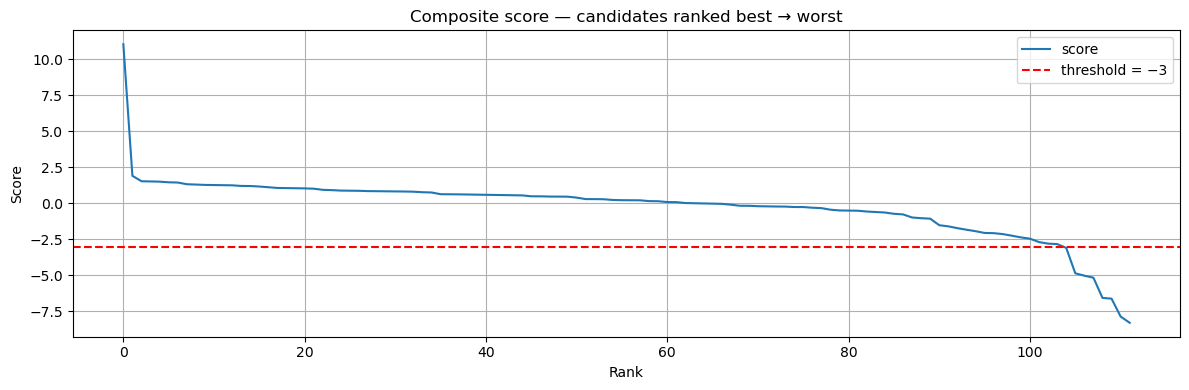

In [11]:
ranked['score'].reset_index(drop=True).plot(
    figsize=(12, 4), grid=True,
    title="Composite score — candidates ranked best → worst",
    xlabel="Rank", ylabel="Score",
)
plt.axhline(-3, color="red", linestyle="--", lw=1.5, label="threshold = −3")
plt.legend(); plt.tight_layout(); plt.show()

In [12]:
ranked_positive = ranked[ranked["score"] > -3]
robust_pairs    = ranked_positive.index
print(f"Candidates: {len(candidates)}  →  Robust pairs (score > −3): {len(robust_pairs)}")

Candidates: 200  →  Robust pairs (score > −3): 104


## 3.4 Pre-filter candidates (composite score)

The composite score from §3.3 is **only a cheap pre-filter** — it narrows the robust pairs down to a short list of candidates. It does **not** pick the traded pair: selecting the single best *in-sample* score is exactly the overfitting trap we want to avoid (it's what produced the inflated CCL/EXPE in-sample Sharpe).

The final pair is chosen in **§3.5** by **walk-forward cross-fold stability**, using only training-span data (2020–2025). The 2026 window (§4b) is never consulted for selection — it stays a genuine held-out test.

In [13]:
# Composite score is a CHEAP PRE-FILTER only — it does NOT pick the final pair.
# Take the top-N robust candidates; the walk-forward driver in §3.5 selects among them.
N_CANDIDATES = 15
wf_candidates = list(robust_pairs[:N_CANDIDATES])

print(f"Pre-filtered to top {len(wf_candidates)} candidates by composite score "
      f"(of {len(robust_pairs)} robust pairs). Final pick is deferred to §3.5.")
for i, (t1, t2) in enumerate(wf_candidates, 1):
    print(f"  {i:2d}. {t1:6s}/{t2:6s}  score={ranked.loc[(t1, t2), 'score']:.3f}")

Pre-filtered to top 15 candidates by composite score (of 104 robust pairs). Final pick is deferred to §3.5.
   1. CCL   /MU      score=11.056
   2. CCL   /EXPE    score=1.919
   3. NCLH  /VMC     score=1.545
   4. CCL   /COF     score=1.531
   5. NCLH  /TEL     score=1.516
   6. NCLH  /O       score=1.470
   7. NCLH  /TMUS    score=1.455
   8. NCLH  /QCOM    score=1.338
   9. NCLH  /TER     score=1.316
  10. NCLH  /PAYX    score=1.290
  11. NCLH  /PRU     score=1.282
  12. NCLH  /SPG     score=1.273
  13. NCLH  /OMC     score=1.261
  14. CCL   /META    score=1.219
  15. CCL   /STT     score=1.212


## 3.5 Walk-forward selection driver  ← *this* picks the traded pair

We run walk-forward validation (rolling train/test folds over the 2020–2025 training span) on **each** pre-filtered candidate and rank by the **median per-fold Sharpe**. Median rewards pairs whose edge is *consistent across folds* rather than pairs that got one lucky window. `MIN_TOTAL_TRADES` screens out pairs too inactive to judge.

This is the holdout principle done correctly for time series: **selection happens on validation folds**; the 2026 test set in §4b is never touched here. The top-ranked pair becomes `ticker1, ticker2` for everything downstream.

The z-score look-back for each test fold is estimated from the *training* fold's residual, which also warms up the rolling window — the test fold never informs its own z-score (no in-fold look-ahead).

In [14]:
# === Walk-forward selection driver (parallel across candidates) =============
# Each candidate's walk-forward run is independent, so we fan them out with joblib.
# walk_forward_backtest is itself serial (no nested parallelism) and the fit uses the
# single-pair _kalman_dynamic_hedge (no internal process pool) — so the only thing to
# guard against is BLAS thread oversubscription. Pin threads to 1 (as the Kalman module
# does internally) before the worker processes are spawned.
import os
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

from joblib import Parallel, delayed
from pairs import walk_forward_backtest, filter_kf_on_new
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals, estimate_halflife_window
from pairs.strategies.evaluate import evaluate_pair_signals

MIN_TOTAL_TRADES = 12   # skip candidates too inactive to rank reliably
N_JOBS = -1             # -1 = all cores; each job is one candidate's walk-forward

prices_wide_tr = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values("datetime"),
    columns=df_filtered.index.get_level_values("ticker"),
    values="close",
)

def _sel_fit_fn(df_train):
    # Filtered (causal) states so the residual history handed to the test fold has the same
    # statistical properties as the causal test-fold residual; the EM fit and the exported
    # end state are identical to mode="smooth".
    _, _, states, params = _kalman_dynamic_hedge(
        "P1", "P2", df_train, q=1e-5, em_iters=5, mode="filter", return_params=True)
    if states is None or params is None:
        return None
    # The z-score look-back is chosen from the TRAINING residual, and that residual is carried
    # along as warm-up history — the test fold never informs its own z-score (no look-ahead).
    params = dict(params)
    params["z_window"]  = estimate_halflife_window(states["resid"])
    params["z_history"] = states["resid"]
    return params

def _sel_signal_fn(df_test, params):
    frozen = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    last_state = (params["last_state_mean"], params["last_state_cov"])
    states_te, _ = filter_kf_on_new(
        df_test["P1"], df_test["P2"],
        frozen=frozen, last_state=last_state, mode="filter")  # causal, no look-ahead
    df_pair_fold = df_test[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner")
    return generate_pair_signals(
        df_pair_fold, z_method="robust",
        z_window=params["z_window"], z_history=params["z_history"],   # from the training fold
        z_entry=2.0, z_exit=0.5, z_stop=4.0, capital_per_pair=10_000)

def _sel_eval_fn(df_test, signals):
    _, _, summary = evaluate_pair_signals(
        df_test[["P1", "P2"]], signals,
        cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252)
    return summary

def _wf_one(t1, t2, df_wf_c, score):
    """Run walk-forward for one candidate; return ('ok', row) / ('error', ...) / None."""
    try:
        res = walk_forward_backtest(
            df_wf_c, train_bars=504, test_bars=126, step_bars=63,
            fit_fn=_sel_fit_fn, signal_fn=_sel_signal_fn, eval_fn=_sel_eval_fn,
            verbose=False)
    except Exception as e:
        return ("error", t1, t2, str(e))
    if res is None or len(res) == 0:
        return None
    s = res["sharpe"].to_numpy(dtype=float)
    n_tr = res["n_trades"].to_numpy(dtype=float)
    return ("ok", {
        "ticker1": t1, "ticker2": t2,
        "wf_sharpe_median": np.nanmedian(s),
        "wf_sharpe_mean":   np.nanmean(s),
        "wf_sharpe_std":    np.nanstd(s),
        "pct_pos_folds":    float(np.mean(s > 0)) if np.isfinite(s).any() else np.nan,
        "wf_trades_total":  int(np.nansum(n_tr)),
        "n_folds":          int(np.isfinite(s).sum()),
        "composite_score":  float(score),
    }, res)

# Build the (small) per-candidate inputs up front; skip pairs with too little history.
_tasks = []
for (t1, t2) in wf_candidates:
    df_wf_c = prices_wide_tr[[t1, t2]].rename(columns={t1: "P1", t2: "P2"}).dropna()
    if len(df_wf_c) < 504 + 126:        # not enough history for even one fold
        continue
    _tasks.append((t1, t2, df_wf_c, float(ranked.loc[(t1, t2), "score"])))

_results = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(_wf_one)(t1, t2, df_wf_c, score) for (t1, t2, df_wf_c, score) in _tasks
)

rows = []
wf_by_pair = {}            # keep each candidate's full per-fold results for reuse
for r in _results:
    if r is None:
        continue
    if r[0] == "error":
        print(f"  skip {r[1]}/{r[2]}: {r[3]}")
        continue
    rows.append(r[1])
    wf_by_pair[(r[1]["ticker1"], r[1]["ticker2"])] = r[2]

wf_selection = pd.DataFrame(rows).set_index(["ticker1", "ticker2"])
wf_selection = wf_selection[wf_selection["wf_trades_total"] >= MIN_TOTAL_TRADES]
wf_selection = wf_selection.sort_values("wf_sharpe_median", ascending=False)

print(f"Ranked {len(wf_selection)} candidates by walk-forward median fold Sharpe "
      f"(>= {MIN_TOTAL_TRADES} total trades):\n")
print(wf_selection.head(10).to_string(float_format="{:.3f}".format))

ticker1, ticker2 = wf_selection.index[0]
wf_results = wf_by_pair[(ticker1, ticker2)]   # winner's folds, for the detail plot below
print(f"\nWalk-forward-selected pair: {ticker1} / {ticker2}")
print("(Composite score chose the SHORTLIST; walk-forward stability chose the PAIR.)")

Ranked 15 candidates by walk-forward median fold Sharpe (>= 12 total trades):

                 wf_sharpe_median  wf_sharpe_mean  wf_sharpe_std  pct_pos_folds  wf_trades_total  n_folds  composite_score
ticker1 ticker2                                                                                                           
CCL     STT                 0.960           0.899          1.109          0.812              149       16            1.212
        EXPE                0.684           0.577          1.200          0.625              136       16            1.919
NCLH    SPG                 0.425           0.567          1.216          0.625              138       16            1.273
        TEL                 0.238           0.089          1.661          0.625              154       16            1.516
        PAYX                0.056           0.051          1.810          0.500              128       16            1.290
CCL     COF                 0.028           0.056          0

### 3.5.1 Walk-forward detail for the selected pair

§3.5 ranked the shortlist by **median per-fold Sharpe** and selected the pair above. Below is that pair's full per-fold walk-forward distribution — the validation evidence behind the choice, reusing the folds already computed (no recomputation). A tight, mostly-positive distribution is what we want; one that swings sign across folds means the edge is fragile.

=== Walk-forward folds for selected pair CCL/STT ===

                   mean    std  median    min     max
sharpe            0.899  1.145   0.960 -1.500   2.654
ann_return        0.132  0.202   0.100 -0.145   0.618
max_drawdown_pct  0.057  0.026   0.051  0.020   0.107
n_trades          9.312  3.240  10.000  5.000  16.000
hit_rate          0.699  0.123   0.708  0.500   0.833
profit_factor    13.032 35.340   1.867  0.431 141.690


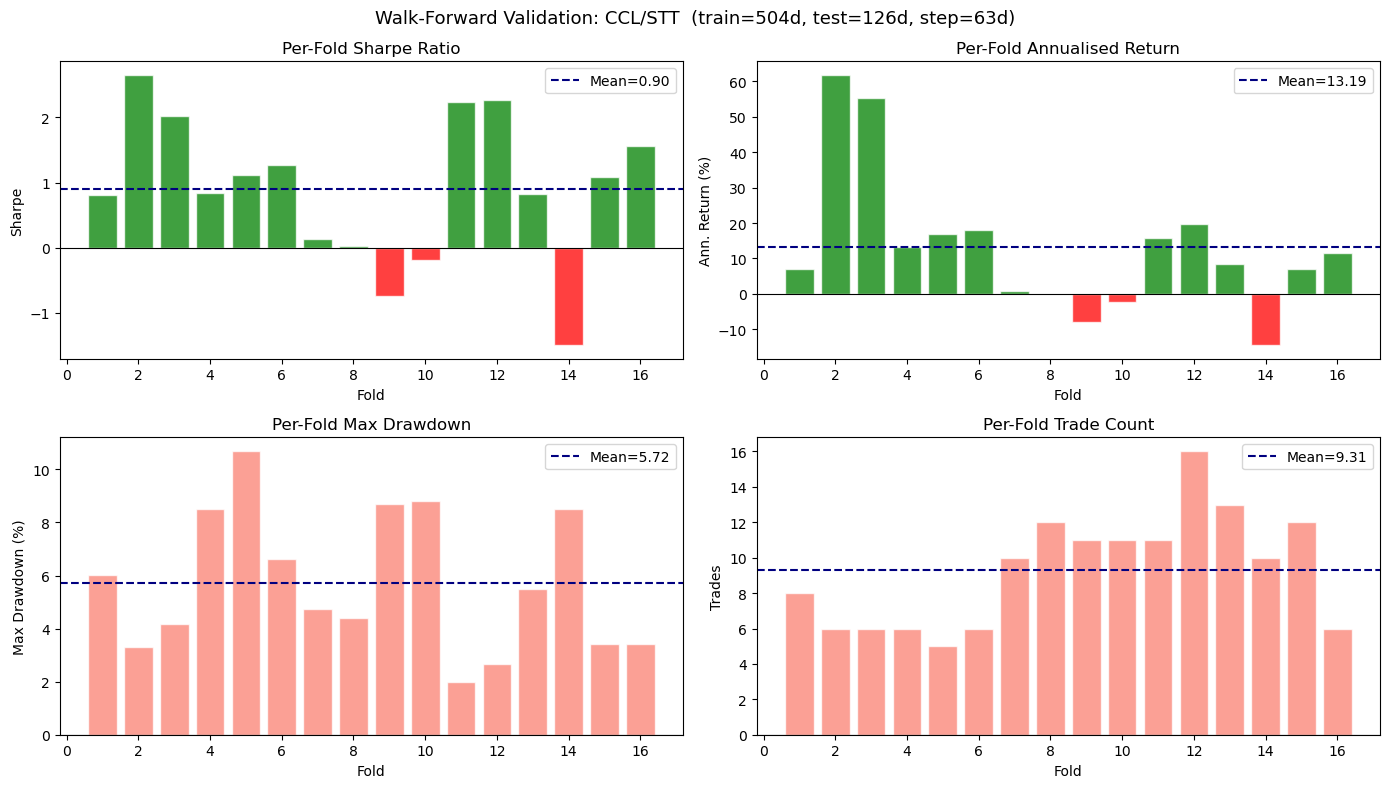


Folds with positive Sharpe : 81%  (13/16)
Median fold Sharpe         : 0.96
Mean fold Sharpe           : 0.90  (std=1.11)


In [15]:
# Per-fold walk-forward detail for the SELECTED pair — reuses wf_results from §3.5
# (no recomputation). nan-robust stats (a zero-trade fold yields a NaN Sharpe).
from pairs.validation.walk_forward import summarize_walk_forward

print(f"=== Walk-forward folds for selected pair {ticker1}/{ticker2} ===\n")
print(summarize_walk_forward(wf_results).to_string(float_format="{:.3f}".format))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Walk-Forward Validation: {ticker1}/{ticker2}  "
             f"(train=504d, test=126d, step=63d)", fontsize=13)

sharpes  = wf_results["sharpe"].to_numpy(dtype=float)
ann_rets = wf_results["ann_return"].to_numpy(dtype=float) * 100
dds      = wf_results["max_drawdown_pct"].abs().to_numpy(dtype=float) * 100
n_trades = wf_results["n_trades"].to_numpy(dtype=float)
folds    = wf_results.index.values

def _bar(ax, vals, title, ylabel, pos_neg=True):
    colors = ["green" if v > 0 else "red" for v in vals] if pos_neg else "salmon"
    ax.bar(folds, vals, color=colors, alpha=0.75, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(np.nanmean(vals), color="navy", linestyle="--", lw=1.5,
               label=f"Mean={np.nanmean(vals):.2f}")
    ax.set_xlabel("Fold"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()

_bar(axes[0, 0], sharpes,  "Per-Fold Sharpe Ratio",      "Sharpe")
_bar(axes[0, 1], ann_rets, "Per-Fold Annualised Return", "Ann. Return (%)")
_bar(axes[1, 0], dds,      "Per-Fold Max Drawdown",      "Max Drawdown (%)", pos_neg=False)
_bar(axes[1, 1], n_trades, "Per-Fold Trade Count",       "Trades", pos_neg=False)
plt.tight_layout(); plt.show()

pct_pos = float(np.mean(sharpes > 0)) * 100
print(f"\nFolds with positive Sharpe : {pct_pos:.0f}%  ({int((sharpes > 0).sum())}/{len(sharpes)})")
print(f"Median fold Sharpe         : {np.nanmedian(sharpes):.2f}")
print(f"Mean fold Sharpe           : {np.nanmean(sharpes):.2f}  (std={np.nanstd(sharpes):.2f})")

# 4. In-Sample Signal Generation & Evaluation (2020–2025)

## 4.1 Build the pair-aligned DataFrame

In [16]:
df_kf = states_tr[(ticker1, ticker2)]

prices = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values('datetime'),
    columns=df_filtered.index.get_level_values('ticker'),
    values='close',
)

df_pair = pd.DataFrame({
    'P1': prices[ticker1],
    'P2': prices[ticker2],
}).join(df_kf[['beta', 'resid']])

print(f"Training pair frame: {df_pair.index[0].date()} → {df_pair.index[-1].date()}, "
      f"{len(df_pair):,} bars")
df_pair.tail(3)

Training pair frame: 2020-01-02 → 2025-12-31, 1,508 bars


,P1,P2,beta,resid
datetime,,,,
2025-12-29,30.719999,131.690002,0.265983,-0.086964
2025-12-30,30.820000,130.339996,0.268277,0.073133
2025-12-31,30.540001,129.009995,0.269112,0.042263


## 4.2 Generate trading signals

Signal logic:
- **Entry**: |z| > `z_entry` (default 2.0) — spread is extreme
- **Exit** : |z| < `z_exit`  (default 0.5) — spread has mean-reverted
- **Stop** : |z| > `z_stop`  (default 4.0) — spread is diverging

Z-score is computed with the *robust* method (median/MAD) which is less sensitive to outliers.

In [17]:
from pairs.strategies import generate_pair_signals

signals = generate_pair_signals(
    df_pair,
    z_method="robust",
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
    max_hold_bars=None,
    cooldown_bars=0,
)
signals.tail(5)

,z,pos,n1,n2,entry,exit,stop
datetime,,,,,,,
2025-12-24,-0.438088,1,148.334272,-40.579473,False,False,False
2025-12-26,-0.947119,0,0.000000,0.000000,False,True,False
2025-12-29,-0.453622,0,0.000000,0.000000,False,False,False
2025-12-30,0.206803,0,0.000000,0.000000,False,False,False
2025-12-31,0.013464,0,0.000000,0.000000,False,False,False


## 4.3 Visualise in-sample trades

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • CCL (top), STT (bottom)'}, ylabel='Price'>))

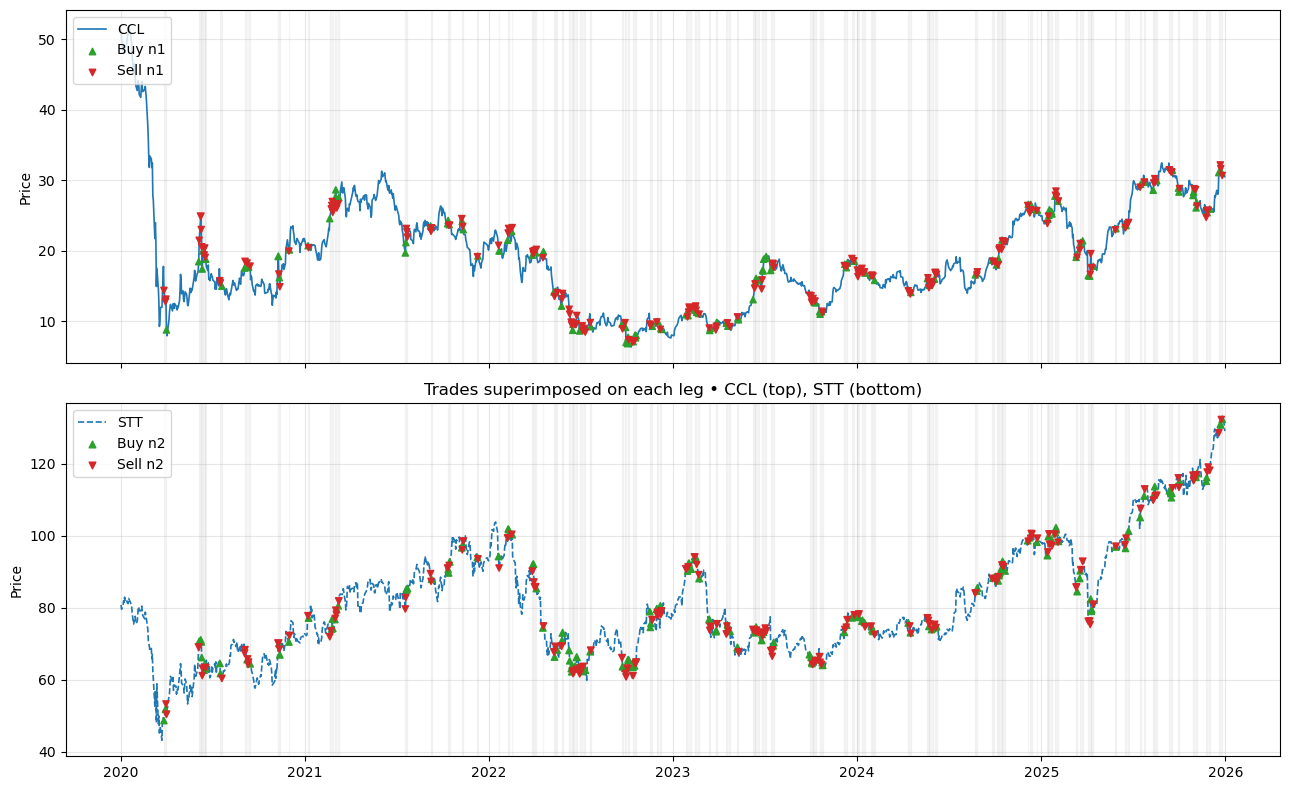

In [18]:
from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair, signals,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
)

## 4.4 In-sample performance metrics

In [19]:
from pairs import evaluate_pair_signals

daily_tr, trades_tr, summary_tr = evaluate_pair_signals(
    df_pair, signals,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
)
print("=== In-Sample Performance (2020-01-02 → 2025-12-31) ===")
print(pd.Series(summary_tr).to_string())

=== In-Sample Performance (2020-01-02 → 2025-12-31) ===
start                       2020-01-02 00:00:00
end                         2025-12-31 00:00:00
bars                                       1508
capital_base                       10008.298817
gross_pnl                           21261.95394
net_pnl                            21061.938536
ann_return                             0.406904
sharpe                                 2.454263
max_drawdown                         1075.68772
max_drawdown_pct                       0.044864
avg_gross_exposure                  1600.510632
avg_exposure_utilization               1.000651
turnover_annualized                     29.3803
n_trades                                     86
hit_rate                               0.918605
avg_win                              281.354121
avg_loss                            -154.182933
profit_factor                         20.594252
avg_hold_bars                          2.802326
med_hold_bars                   

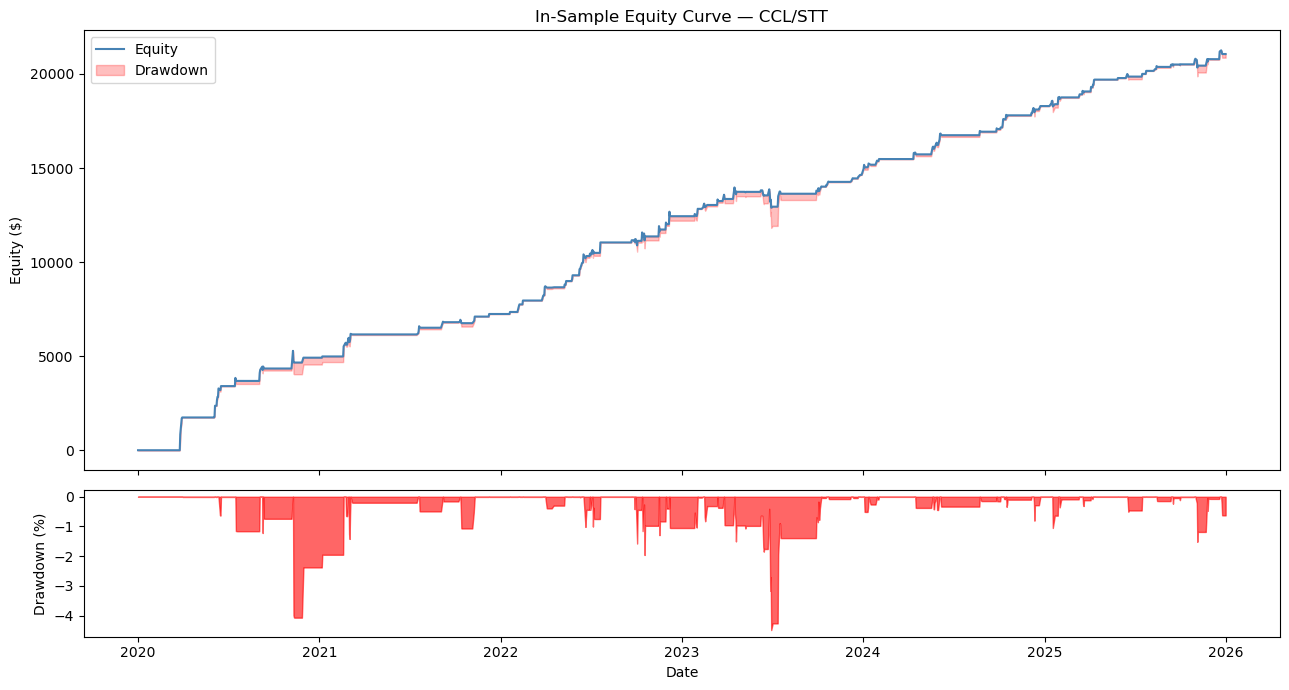

In [20]:
# Equity curve with drawdown shading
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(daily_tr.index, daily_tr["equity"], color="steelblue", lw=1.5, label="Equity")
ax1.fill_between(daily_tr.index, daily_tr["equity"],
                 daily_tr["equity"] + daily_tr["drawdown"],   # drawdown is negative
                 alpha=0.25, color="red", label="Drawdown")
ax1.set_ylabel("Equity ($)"); ax1.set_title(f"In-Sample Equity Curve — {ticker1}/{ticker2}")
ax1.legend()

ax2.fill_between(daily_tr.index, daily_tr["drawdown_pct"] * 100, 0,
                 alpha=0.6, color="red")
ax2.set_ylabel("Drawdown (%)"); ax2.set_xlabel("Date")
plt.tight_layout(); plt.show()

# 4b. Out-of-Sample Evaluation (2026-01-01 → 2026-06-25)

## 4b.1 Download OOS price data

In [21]:
start_test = "2026-01-01"
end_test   = "2026-06-25"

df_test, failed = load_prices('openbb', [ticker1, ticker2], start_test, end_test, return_failed=True)
print(f"OOS data: {len(df_test):,} rows, {df_test.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)

Download:   0%|          | 0/2 [00:00<?, ?it/s]

CCL:   0%|          | 0/2 [00:00<?, ?it/s]     

CCL:  50%|█████     | 1/2 [00:00<00:00,  4.03it/s]

STT:  50%|█████     | 1/2 [00:00<00:00,  4.03it/s]

STT: 100%|██████████| 2/2 [00:00<00:00,  4.42it/s]

STT: 100%|██████████| 2/2 [00:00<00:00,  4.35it/s]

OOS data: 240 rows, 2 tickers


## 4b.2 Continue Kalman filter on OOS window (no look-ahead)

We freeze the parameters $(F, Q, R)$ learned during training and **continue filtering**
from the last train state.  The smoother is NOT used on OOS data — only the causal filter.

The OOS z-score uses a look-back chosen from — and warmed up on — the causal *training-window* residual under the same frozen parameters, so the OOS window never informs its own z-score.

In [22]:
from pairs import filter_kf_on_new

pair = (ticker1, ticker2)
frozen = {k: params_tr[pair][k] for k in ("F", "Q", "R")}
last_state = (params_tr[pair]["last_state_mean"], params_tr[pair]["last_state_cov"])

P1_new = df_test.loc[(ticker1,), 'close']
P2_new = df_test.loc[(ticker2,), 'close']

states_te, _ = filter_kf_on_new(
    P1_new, P2_new,
    frozen=frozen,
    last_state=last_state,
    init_cov=1e6,
    mode="filter",
)

prices_te = df_test.pivot_table(
    index=df_test.index.get_level_values("datetime"),
    columns=df_test.index.get_level_values("ticker"),
    values="close",
)
df_pair_te = states_te.join(
    prices_te[[ticker1, ticker2]].rename(columns={ticker1: "P1", ticker2: "P2"}),
    how="inner",
)
print(f"OOS pair frame: {df_pair_te.index[0].date()} → {df_pair_te.index[-1].date()}, "
      f"{len(df_pair_te):,} bars")

OOS pair frame: 2026-01-02 → 2026-06-25, 120 bars


In [23]:
# z-score look-back and warm-up history from the causal TRAINING residual under the frozen
# parameters — the OOS window never informs its own z-score (no in-window look-ahead).
states_hist, _ = filter_kf_on_new(
    df_pair["P1"], df_pair["P2"],
    frozen=frozen, last_state=None, init_cov=1e6, mode="filter",
)
z_window_tr = estimate_halflife_window(states_hist["resid"])
print(f"z-score window from training residual: {z_window_tr} bars")

signals_te = generate_pair_signals(
    df_pair_te,
    z_method="robust",
    z_window=z_window_tr, z_history=states_hist["resid"],
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
)
daily_te, trades_te, summary_te = evaluate_pair_signals(
    df_pair_te[["P1", "P2"]], signals_te,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
)
print("=== Out-of-Sample Performance (2026-01-01 → 2026-06-25) ===")
print(pd.Series(summary_te).to_string())

z-score window from training residual: 30 bars
=== Out-of-Sample Performance (2026-01-01 → 2026-06-25) ===
start                       2026-01-02 00:00:00
end                         2026-06-25 00:00:00
bars                                        120
capital_base                        9982.860722
gross_pnl                            695.049266
net_pnl                              678.794022
ann_return                             0.147801
sharpe                                 1.438988
max_drawdown                         332.334722
max_drawdown_pct                       0.032708
avg_gross_exposure                  1751.634176
avg_exposure_utilization               1.002652
turnover_annualized                   29.881713
n_trades                                      7
hit_rate                               0.857143
avg_win                               135.74002
avg_loss                            -128.716029
profit_factor                          6.327418
avg_hold_bars                

## 4b.3 Visualise OOS trades

The same view as the in-sample plot (§4.3), now on the 2026 held-out window. Reading it next to §4.3 makes the regime change concrete — far fewer shaded holding periods reflect the ~6 OOS trades.

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • CCL (top), STT (bottom)'}, ylabel='Price'>))

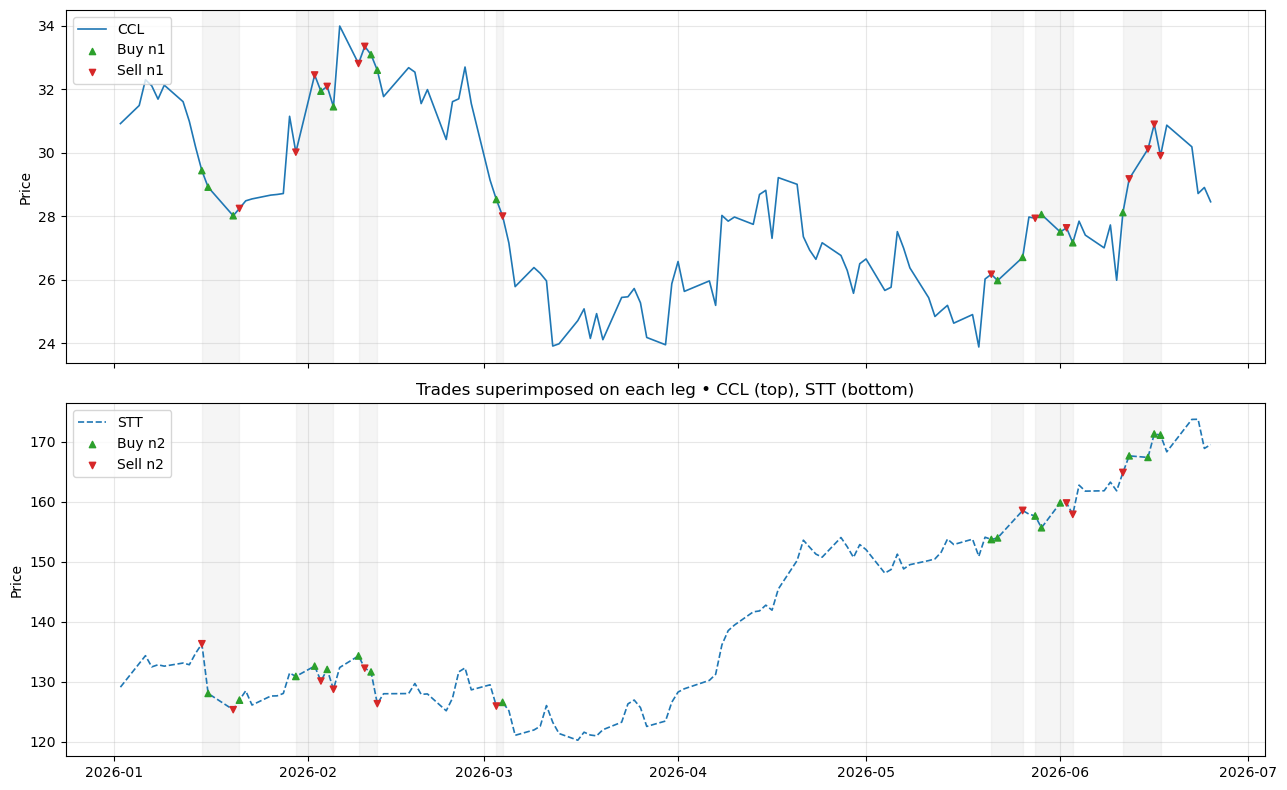

In [24]:
# Same plot as in-sample (§4.3), applied to the OOS pair frame & signals.
from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair_te, signals_te,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
)

## 4b.4 In-sample vs OOS comparison

> ⚠️ **Caution**: The OOS window contains only **7 trades**.  A hit rate of 86%
> on 7 observations is statistically uninformative — the 95% binomial CI spans
> roughly (42%, 99.6%).  The Sharpe decay is real but its magnitude is uncertain.

In [25]:
comparison = pd.DataFrame({
    "In-sample (2020-2025)": pd.Series(summary_tr),
    "OOS (2026)":            pd.Series(summary_te),
}).loc[["sharpe", "ann_return", "max_drawdown_pct", "n_trades", "hit_rate", "profit_factor"]]
comparison.loc["ann_return"] = comparison.loc["ann_return"] * 100   # → %
comparison.index = ["Sharpe", "Ann. Return (%)", "Max Drawdown (%)", "Trades", "Hit Rate", "Profit Factor"]
print(comparison.to_string(float_format="{:.3f}".format))

                 In-sample (2020-2025) OOS (2026)
Sharpe                           2.454      1.439
Ann. Return (%)                 40.690     14.780
Max Drawdown (%)                 0.045      0.033
Trades                              86          7
Hit Rate                         0.919      0.857
Profit Factor                   20.594      6.327


# 8. Limitations and Honest Assessment

## 8.1 What the results cannot tell us

The traded pair was chosen (§3.5) from a shortlist that itself survived a composite stationarity filter over a very large number of simultaneously-tested pairs. Read the performance with these caveats:

- **Selection bias (amplified — no BH here).** This notebook omits Benjamini-Hochberg correction, so the screen admits more statistically spurious pairs than `pairs_trading_02.ipynb`. Walk-forward selection still helps and the OOS window is held out, but with no multiple-testing control the candidate set is noisier and selection bias is worse than in nb02.
- **Low OOS trade count.** The OOS window typically produces only a handful of trades (7 for the selected CCL/STT pair) — far below the ~50 needed for statistical power. A high hit rate on a few trades is uninformative.
- **OOS Sharpe decay.** In-sample Sharpe is systematically optimistic and the OOS figure is typically much lower. Likely causes: over-fitting to COVID-era volatility, cointegration breakdown, and regimes (e.g. an AI bull market) offering fewer reversion opportunities.
- **Optimistic cost model.** The in-sample/OOS evaluation uses a flat `cost_bps` with no market impact, fill/queue uncertainty, or borrow-availability variability.
- **Single-pair analysis.** A live strategy trades a *portfolio* of pairs — introducing cross-pair residual correlation, portfolio-level drawdown management, and signal interaction effects not captured here.

## 8.2 What the evidence does support

1. A working end-to-end pipeline (data → cointegration → Kalman hedge → signals → evaluation) with **causal OOS continuation** (no look-ahead: the Kalman state is carried forward, and the z-score look-back and its warm-up come from training data, never from the window being scored).
2. **Honest pair selection**: the traded pair is chosen by walk-forward cross-fold stability (§3.5), not by in-sample ranking — and the held-out window is never used for selection.
3. **Multiple-testing _not_ corrected**: this variant omits BH FDR (the deliberate difference from nb02), so statistically spurious pairs that BH would remove stay in the candidate set.
4. **Honest degradation disclosure**: the OOS Sharpe is reported, not hidden, and the walk-forward distribution (§3.5.1) shows the spread across folds rather than one window.

## 8.3 Gap-to-production

| Gap | Required mitigation |
|-----|---------------------|
| Selection bias | Strict hold-out from inception; **add BH FDR** (omitted here — see nb02) + walk-forward selection |
| Low OOS N | Longer OOS window; portfolio of 10+ pairs |
| No market impact | Square-root impact model + capacity analysis |
| Single-regime OOS | Rolling re-estimation in live trading |
| No portfolio risk mgmt | Residual-vol position sizing; cross-pair correlation |
| Borrow / execution | Pre-borrow checks; limit-order fill model |